# Supporting diagnostics — pressure, flexure, equilibration (MDOODZ single step)

Diagnostics that support the force-balance analysis in `force_balance_single_step.ipynb` by testing its assumptions in the same MDOODZ model snapshot. Model description: [`MODEL.md`](../MODEL.md); notation: the umbrella project's `SYMBOLOGY.md`.

* **Pressure at the compensation depth** (`z_c_depth`): how valid is the hydrostatic assumption for the asthenosphere — is pressure approximately constant along equipotential surfaces? Departures from this are what would usually be called dynamic topography.

* **The vertical shear resultant $V$ and its gradient $dV/dx$**: gradients in $V$ generate non-isostatic topography (equivalently, $\tau_{zx,x}/g$ acts as an equivalent density $\hat\rho$ in the vertical normal stress). This relationship underpins classic thin-plate flexure; here it is evaluated directly in a fully resolved model, which makes it possible to ask how much of the trench topography is non-isostatic — spoiler alert: essentially all of it.

* **Depth profiles of stress** in the trench–outer-rise region: where the between-column difference in $\sigma_{zz}$ equilibrates with depth, and how that equilibration depth relates to the mechanical thickness $h_m$ and the neutral-plane depth $h_{np}$.



In [1]:
#import pyvista as pv
import numpy as np
import glob
import natsort
import matplotlib.pyplot as plt
import h5py
from scipy.integrate import trapz, cumulative_trapezoid
from scipy.ndimage import gaussian_filter
from scripts.helpers import *

plt.rcParams.update({
    "mathtext.fontset": "cm",  
    "font.family": "serif",     
})


In [2]:
data_dir = '../model_output_data/MD7_R0/'

In [3]:
# ---------------------------------------------------------------------
# PHYSICAL CONSTANTS AND DOMAIN SETUP
# ---------------------------------------------------------------------
delrho     = 3250
g          = 9.81
s2my       = 3.1436e13
#integration depth limit
z_c_depth  = 100e3
ref_file_indx = 10

## 1. Setup and data 

In [4]:
#Load one of the HDF5 files to get some information on the grid
h5_fnames = natsort.natsorted(glob.glob(data_dir  + '*.h5')) 

# Loop through all .h5 files
for index, h5_fname in enumerate(h5_fnames):
    # Open the file using a context manager
    with h5py.File(h5_fname, 'r') as h5file:
        # Extract the time value from the file
        time = h5file["/Model/Params"][0].astype(int) / s2my
        # Print the file index and formatted time
        print(f"File index: {index}, Time step: {time:.1f} Myrs")

File index: 0, Time step: 0.0 Myrs
File index: 1, Time step: 0.2 Myrs
File index: 2, Time step: 0.6 Myrs
File index: 3, Time step: 1.0 Myrs
File index: 4, Time step: 1.4 Myrs
File index: 5, Time step: 1.8 Myrs
File index: 6, Time step: 2.2 Myrs
File index: 7, Time step: 2.6 Myrs
File index: 8, Time step: 3.0 Myrs
File index: 9, Time step: 3.4 Myrs
File index: 10, Time step: 3.8 Myrs
File index: 11, Time step: 4.3 Myrs
File index: 12, Time step: 4.7 Myrs
File index: 13, Time step: 5.1 Myrs
File index: 14, Time step: 5.6 Myrs
File index: 15, Time step: 6.0 Myrs
File index: 16, Time step: 6.5 Myrs
File index: 17, Time step: 6.9 Myrs
File index: 18, Time step: 7.4 Myrs
File index: 19, Time step: 7.8 Myrs
File index: 20, Time step: 8.2 Myrs
File index: 21, Time step: 8.6 Myrs
File index: 22, Time step: 9.0 Myrs
File index: 23, Time step: 9.4 Myrs
File index: 24, Time step: 9.7 Myrs
File index: 25, Time step: 10.1 Myrs
File index: 26, Time step: 10.5 Myrs
File index: 27, Time step: 10.9 Myrs

In [5]:
# ---------------------------------------------------------------------
# Select model snapshot and open corresponding HDF5 file
# ---------------------------------------------------------------------

# Choose which output file to analyse.
# (Negative indices count from the end; e.g. -1 = latest timestep)
file_index_number = ref_file_indx 

# Open the selected model output
h5file = h5py.File(h5_fnames[file_index_number], 'r')

# Access global model parameters
data = h5file['/Model/Params']

# Extract and convert model time from seconds to Myr
time = h5file['/Model/Params'][0].astype(int) / s2my

print(f" Time step: {time:.1f} Myr")

 Time step: 3.8 Myr


In [6]:
# ---------------------------------------------------------------------
# Mesh setup and geometric parameters
# ---------------------------------------------------------------------

#these are not easy to unabigoously define from the mesh, 
#so we just hardcode them 
xmin       = -1600e3
xmax       = 1600e3
zmin       = -20e3
zmax       = 660e3

# Nx, Nz = number of VERTICES in the x and z directions
# (each grid cell is bounded by 2 vertices ⇒ there are Nx−1 and Nz−1 cell centers)
Nx  = data[3].astype(int)
Nz  = data[4].astype(int)

# Nominal grid spacing (m)
# use ceil to avoid small floating-point rounding errors when reconstructing domain
dx  = np.ceil((xmax - xmin) / (Nx - 1))   # horizontal spacing (m)
dz  = np.ceil((zmax - zmin) / (Nz - 1))   # vertical spacing (m)

# Vertex coordinates (boundaries of cells)
vxpts = np.linspace(xmin, xmax, Nx)       # x-coordinates of vertices
vzpts = np.linspace(zmin, zmax, Nz)       # z-coordinates of vertices

# Cell-center coordinates (midpoints between adjacent vertices)
cxpts = 0.5 * (vxpts[1:] + vxpts[:-1])    # x-centers of cells  → length Nx−1
czpts = 0.5 * (vzpts[1:] + vzpts[:-1])    # z-centers of cells  → length Nz−1

# ---------------------------------------------------------------------
# Indices for reference depths / limits
# ---------------------------------------------------------------------

# Index of the vertical vertex just beyond the integration limit z_c_depth
# (used for selecting the deepest vertical integration slice)
#vbase_indx = np.argmin(np.abs(vzpts - z_c_depth))
vbase_indx = vertical_index(z_c_depth, vzpts)

# Index of the cell center nearest to z_c_depth
# (used when plotting or sampling quantities defined on cell centers)
cbase_indx = vertical_index(z_c_depth, czpts)


In [7]:
# ---------------------------------------------------------------------
# Load and prepare topography array from HDF5 file
# ---------------------------------------------------------------------

# Attempt to read "x" and "z" coordinates for surface topography.
# Some model outputs store these under 'x_mark'/'z_mark' instead of 'x'/'z'.
try:
    topo_ = np.column_stack((
        h5file["/Topo"]["x_mark"][:],
        h5file["/Topo"]["z_mark"][:]
    ))
except KeyError:
    topo_ = np.column_stack((
        h5file["/Topo"]["x"][:],
        h5file["/Topo"]["z"][:]
    ))

# Initialise a 3-column array for convenience.
# Columns: [x, z, (reserved placeholder for later derived quantity)]
new_array = np.zeros((topo_.shape[0], 3))
new_array[:, :2] = topo_

# Sort rows by x-coordinate to ensure monotonic topography profile
topo = new_array[np.argsort(new_array[:, 0])]


# ---------------------------------------------------------------------
# Identify trench position and reference index
# ---------------------------------------------------------------------

# The trench is defined as the x-position of the topographic minimum
x_trench = topo[:, 0][np.argmin(topo[:, 1])]

# Find the first mesh vertex located to the right of the trench
tindx = np.argmax(cxpts > x_trench)


# ---------------------------------------------------------------------
# Interpolate topography to the model mesh
# ---------------------------------------------------------------------

# Interpolate the topographic surface to vertex x-points (vxpts)
# → topo_mesh has same length as cxpts, providing z-topo at each vertex
topo_mesh = np.interp(cxpts, topo[:, 0], topo[:, 1])


In [8]:
#topo_.shape

In [9]:
# ---------------------------------------------------------------------
# Load and orient stress components from HDF5, assuming z is positive downward
# ---------------------------------------------------------------------

# Shear stress τ_zx (traction in x on face normal to z)
# Stored at vertices → flip vertically to ensure z increases downward
tau_zx_grid = -1 * np.flipud(h5file["/Vertices"]["sxz"][:].reshape(Nz, Nx))

# Pressure P (cell-centered) → flip vertically to match same orientation
pressure_grid = np.flipud(h5file["/Centers"]["P"][:].reshape(Nz-1, Nx-1))

# Mean (isotropic) stress: σ_I = −P
sigma_I_grid = -1 * pressure_grid                         # (Nz-1, Nx-1)

# Deviatoric normal stresses τ_xx and τ_zz = −τ_xx (plane strain assumption)
tau_xx_grid = np.flipud(h5file["/Centers"]["sxxd"][:].reshape(Nz-1, Nx-1))
tau_zz_grid = -1 * tau_xx_grid

# ---------------------------------------------------------------------
# Reconstruct total normal stresses at cell centers
# ---------------------------------------------------------------------

# Total σ_xx = σ_I + τ_xx
sig_xx_grid = sigma_I_grid + tau_xx_grid
# Total σ_zz = σ_I + τ_zz
sig_zz_grid = sigma_I_grid + tau_zz_grid

# For plane strain, σ_xx − σ_zz = 2 τ_xx
diff_stress_grid = tau_xx_grid - tau_zz_grid


# ---------------------------------------------------------------------
# load temperatrue grid
# ---------------------------------------------------------------------
temp_grid = np.flipud(h5file["/Centers"]['T'][:].reshape(Nz-1, Nx-1))


In [10]:
#cint_mas

**simple mpl plot**

In [11]:
# ---------------------------------------------------------------------
# Determine horizontal bounds where temperature drops below 0.9 × Tₘₐₓ
# ---------------------------------------------------------------------

# Extract the temperature field along the chosen integration depth (z = z_c_depth)
# using the precomputed cell-center index (cbase_indx)
temp_at_int_lim = temp_grid[cbase_indx, :]

# Boolean mask: identify where temperature < 90% of the domain maximum
below_threshold = temp_at_int_lim < 0.9 * temp_grid.max()

# Indices of the first and last points where the condition is satisfied
start_idx = np.argmax(below_threshold)                                # first below threshold
end_idx = len(below_threshold) - np.argmax(below_threshold[::-1]) - 1 # last below threshold

# Corresponding x-locations (relative to trench)
x_bounding_start = cxpts[start_idx] - x_trench
x_bounding_end   = cxpts[end_idx]   - x_trench

# Bounding interval relative to trench (m)
x_bounding_start, x_bounding_end

(-216526.96875, -80526.96875)

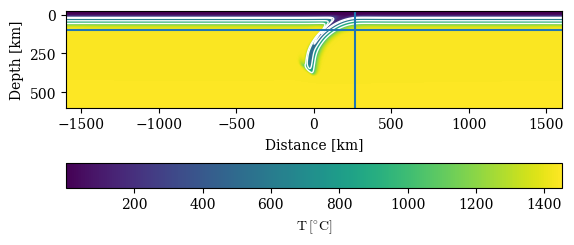

In [12]:
fig, ax = plt.subplots()

# Plot the heatmap with coordinate axes


im = ax.imshow(temp_grid - 273, extent=1e-3*np.array([cxpts.min(), cxpts.max(), czpts.max(), czpts.min()]), 
               origin="upper", cmap="viridis")


# Add a colorbar
cbar = fig.colorbar(im, ax=ax, label=r"$\mathrm{T\, [^{\circ}C]}$", orientation="horizontal" , fraction=0.1, pad=0.15)


# Convert contour levels to Kelvin
contour_levels_C = [600, 700, 1000, 1300]
contours = ax.contour(1e-3*cxpts, 1e-3*czpts, temp_grid, levels=contour_levels_C, colors='white', linewidths=1)

ax.hlines(1e-3*z_c_depth, 1e-3*cxpts.min(), 1e-3*cxpts.max())
ax.vlines(1e-3*x_trench, 1e-3*czpts.min(), 1e-3*czpts.max())


# Labels and legend
ax.set_xlabel("Distance [km]")
ax.set_ylabel("Depth [km]")
#ax.legend()
ax.set_aspect(1)
ax.set_xlim(1e-3*cxpts.min(), 1e-3*cxpts.max())
ax.set_ylim(600, -20)

plt.show()

## 2. Stress along the basal boundary ($z = z_c$)

* here we evaluate the pressure variation and the cumulative shear stress (x-traction) along the chosen equipotential surface, which defines the lower limit for the force balance (set with the `z_c_depth` variable).
* by default the `z_c_depth` is set to 100 km, which is slightly larger than the thermal thickness of the lithosphere in the numerical model $h_t \approx 80 km$.



In [13]:
# so that we have a consistent set of x coords for this plt,  we map shear stresses to face centered
tau_zx_hface = vertices_to_horizontal_faces(tau_zx_grid)


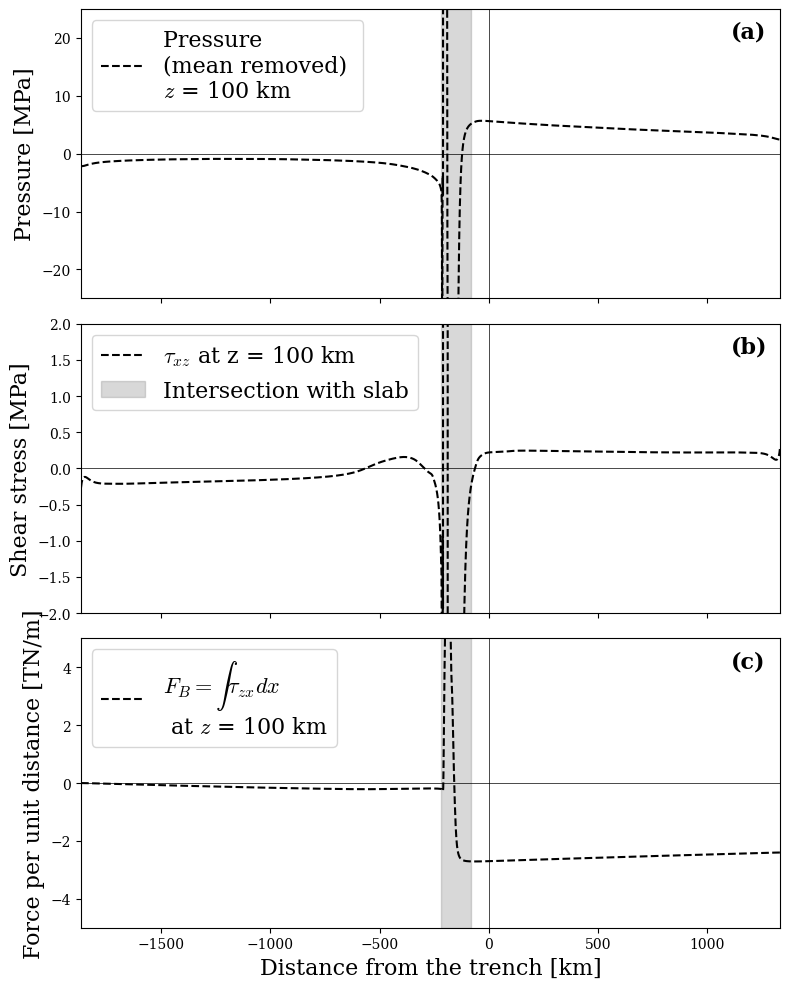

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# (a) Pressure Variation
ax = axes[0]
ax.plot(1e-3*(cxpts - x_trench), 
        1e-6*pressure_grid[cbase_indx,:] - 
        1e-6*pressure_grid[cbase_indx,:].mean(), 
        c='k', lw=1.5, ls='--', label='Pressure \n(mean removed) \n'+ '$z$ = {:.0f} km'.format(z_c_depth / 1e3) )

ax.plot([0, 0], [-100, 100], color='k', lw=0.5)
ax.hlines(0, 1e-3*(cxpts.min() - x_trench), 1e-3*(cxpts.max() - x_trench), color='k', lw=0.5)
ax.axvspan(1e-3*x_bounding_start, 1e-3*x_bounding_end, color='grey', alpha=0.3)

ax.set_ylim(-25, 25)
ax.set_ylabel('Pressure [MPa]', fontsize=16)
ax.legend(loc=2, fontsize=16)
ax.text(0.93, 0.9, '(a)', transform=ax.transAxes, fontsize=16, fontweight='bold')

# (b) Shear Stress
ax = axes[1]
ax.plot(1e-3*(cxpts - x_trench), 
        1e-6*tau_zx_hface[cbase_indx,:], 
        c='k', lw=1.5, ls='--', label = r'$\tau_{{xz}}$ at z = {:.0f} km'.format(z_c_depth / 1e3))

ax.plot([0, 0], [-100e6, 100e6], color='k', lw=0.5)
ax.hlines(0, 1e-3*(cxpts.min() - x_trench), 1e-3*(cxpts.max() - x_trench), color='k', lw=0.5)
ax.axvspan(1e-3*x_bounding_start, 1e-3*x_bounding_end, color='grey', alpha=0.3,  label='Intersection with slab')

ax.set_ylim(-2, 2)
ax.set_ylabel('Shear stress [MPa]', fontsize=16)
ax.legend(loc=2, fontsize=16)
ax.text(0.93, 0.9, '(b)', transform=ax.transAxes, fontsize=16, fontweight='bold')

# (c) Cumulative Integral of Shear Stress
ax = axes[2]
ax.plot(1e-3*(cxpts - x_trench), 
        1e-12*1e3*np.cumsum(tau_zx_hface[cbase_indx,:]), 
        c='k', lw=1.5, ls='--', 
        label=r'$ F_B = \int \tau_{zx} dx$'+ '\n' +' at $z$ = {:.0f} km'.format(z_c_depth / 1e3) )

ax.plot([0, 0], [-100e6, 100e6], color='k', lw=0.5)
ax.hlines(0, 1e-3*(cxpts.min() - x_trench), 1e-3*(cxpts.max() - x_trench), color='k', lw=0.5)
ax.axvspan(1e-3*x_bounding_start, 1e-3*x_bounding_end, color='grey', alpha=0.3)


ax.set_xlim(1e-3*(xmin - x_trench), 1e-3*(xmax - x_trench))
ax.set_ylim(-5, 5)
ax.set_xlabel('Distance from the trench [km]', fontsize=16)
ax.set_ylabel('Force per unit distance [TN/m]', fontsize=16)
ax.legend(loc=2, fontsize=16)
ax.text(0.93, 0.9, '(c)', transform=ax.transAxes, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


#fig.savefig('./figures/horiz_slice.png', dpi=100, facecolor='white', bbox_inches='tight')

**Interpretation**

* Seaward of the trench, the pressure variation ($\Delta P_{z_c}$) along an equipotential surface (i.e. $z_c$ =constant) is very small, less than 1 MPa per 100 km.
* Meanwhile, the trench pressure deficit due to trench topography $\Delta P_T = (\rho_m - \rho_w) g w_T $, is around 50 MPa over a similar length scale. 
* Hence $\Delta P_{z_c} \ll \Delta P_T $, which is consistent with the (hydrostatic) approximation used in the manuscript. 

## 3. Flexural support of trench topography and $\Delta \mathrm{GPE}^*$ estimate

In this section we:
* estimate the **flexurally supported component** of the topography,
* calculate the location of the **nearest isostatic column** to the trench, and
* estimate the **trench pull force** based on the scaling relationship defined in the manuscript.

In the classic thin plate flexure model, the vertical force balance is typically expressed as:

$\frac{dV}{dx} = -q$

where $V$ is the vertical shear stress resultant, and the normal load ($q$) is the given by the isostatic restoring force: 

\begin{equation}
q = (\rho_m - \rho_w) g w(x)
\end{equation}

Here, $V$ is approximated by integrating the **vertical component of the traction** $\tau_{zx}\cdot \hat n$ down to the assumed compensation level $z_c$, and the horizontal gradient ($\frac{dV}{dx}$) is approximated using the numpy gradient function. 


We can compare the actual **model topographic variation** in the plate seaward of the trench with the **topographic variation implied by the gradients in $V$**.

The condition $\frac{dV}{dx} = 0$ corresponds to a location where the column experiences no flexural support. Seaward of the trench, the first location where this condition is met defines the **first isostatic column**, denoted $x_I$.




In [15]:
#cxpts.shape

In [16]:
# ---------------------------------------------------------------------
# 1. Map vertex-based τ_zx (stored as tau_zx_grid) to vertical face centers
# ---------------------------------------------------------------------
tau_zx_vface = vertices_to_vertical_faces(tau_zx_grid)  # (Nz-1, Nx)
#tau_zx_vface_masked = tau_zx_vface[cint_mask, :]         # apply vertical mask (above z_c_depth)

# ---------------------------------------------------------------------
# 2. Integrate τ_zx vertically to get cumulative horizontal traction (N/m)
#    Negative sign accounts for downward-pointing unit vector (z positive down)
# ---------------------------------------------------------------------
Vx = -1 * trapz(tau_zx_vface, dx=dz, axis=0)  # integrate over z, result shape (Nx,)
Vx = 0.5 * (Vx [:-1] + Vx [1:])

# ---------------------------------------------------------------------
# 3. Compute horizontal gradient (∂Vx/∂x) using centered finite differences
#    This gives horizontal change in integrated shear traction (N/m²)
# ---------------------------------------------------------------------
dVdx = np.gradient(Vx, dx)

# ---------------------------------------------------------------------
# 4. Compute the "no-isostatic" vertical deflection supported by this stress gradient
#    v_topo = (1 / Δρg) * ∂Vx/∂x
# ---------------------------------------------------------------------
vtopo = dVdx / (delrho * g)

# ---------------------------------------------------------------------
# 5. Locate the first isostatic column (first zero-crossing of dV/dx)
# ---------------------------------------------------------------------
window = 500  # search range in km (or adjusted if vxpts in m)
mask_x = vxpts > x_trench
tau_sum = np.sum(tau_zx_vface, axis=0)[mask_x]
indx = np.argmin(-1 * tau_sum[:window])
xi_loc = vxpts[mask_x][:window][indx]
xi_indx = np.argmin(np.abs(vxpts - xi_loc))
xi_dist = xi_loc - x_trench

# ---------------------------------------------------------------------
# 6. Compute trench-relative topographic difference (w_T in paper)
# ---------------------------------------------------------------------
trench_relative_topo = (
    topo[:, 1][np.argmin(np.abs(topo[:, 0] - xi_loc))] -
    topo[:, 1][np.argmin(np.abs(topo[:, 0] - x_trench))]
)

# ---------------------------------------------------------------------
# 7. Find midpoint between trench and first isostatic column (useful reference)
# ---------------------------------------------------------------------
xm_indx = int(tindx + 0.5 * (xi_indx - tindx))


/var/folders/50/4pb6cyv53tq0fmpjrm94qgdc0000gn/T/ipykernel_59007/811938889.py:11: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  Vx = -1 * trapz(tau_zx_vface, dx=dz, axis=0)  # integrate over z, result shape (Nx,)


In [17]:
#this is a depth mask to limit the search for the neutral plane, 
#or the zero-crossing of the function tau_xx - tau_zz 
np_mask = np.logical_and(czpts>10e3, czpts<50e3)

# Extract the masked array and corresponding x-values
z_vals = diff_stress_grid[:, xm_indx][np_mask]
x_vals = czpts[np_mask]

# Find indices where the sign changes (zero crossing)
sign_changes = np.where(np.diff(np.sign(z_vals)))[0]

# If a zero crossing exists, interpolate
if len(sign_changes) > 0:
    idx = sign_changes[0]  # Take the first crossing
    x1, x2 = x_vals[idx], x_vals[idx + 1]
    y1, y2 = z_vals[idx], z_vals[idx + 1]

    # Linear interpolation for zero crossing
    np_depth = x1 - y1 * (x2 - x1) / (y2 - y1)
    print(f"Interpolated neutral plane crossing at z = {1e-3*np_depth:.1f} km")
else:
    print("No zero crossing found within the specified range.")

Interpolated neutral plane crossing at z = 29.0 km


In [18]:
#estimate of the `trench pull force' using the scaling relationship from the paper
gpe_est = trench_relative_topo*delrho*g*np_depth

print(f"Trench Relative Topo: {1e-3*trench_relative_topo:.2f} km")
print(f"Neutral plane depth: {1e-3*np_depth:.2f} km")
print(f"Trench pull force (scaling estimate): {gpe_est*1e-12:.2f} TN/m")

Trench Relative Topo: 1.84 km
Neutral plane depth: 29.00 km
Trench pull force (scaling estimate): 1.70 TN/m



**Plot the shear stress resultant ($V$), and ($dV/dx$)**

Text(0, 0.5, 'Force per unit distance [TN/m]')

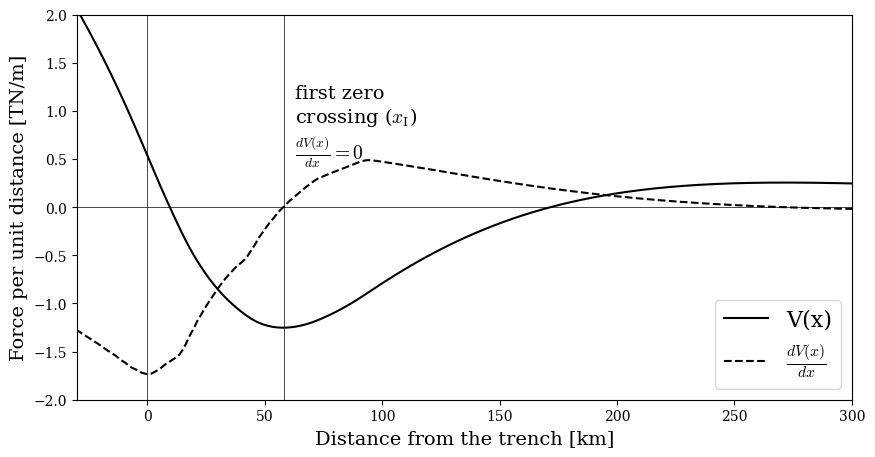

In [19]:
#fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig, ax = plt.subplots( figsize=(10, 5), sharex=True)


# Plot topography on the first axis

ax.plot(1e-3*(cxpts - x_trench), 1e-12*Vx, c = 'k', label = 'V(x)')

#use an arbitrary scale factor - all we want to do is see the shape of the dV/dv and location zero-crossing
sf = 3e4
#sf =1
ax.plot(1e-3*(cxpts - x_trench), sf*1e-12*dVdx, c = 'k',ls='--', label = r'$\frac{dV(x)}{dx}$')

ax.vlines(0, -5, 5, color='k', lw=0.5)
ax.vlines(1e-3*(xi_loc - x_trench), -5, 5, color='k', lw=0.5)
ax.set_xlim(-30, 300)
ax.hlines(0, -100, 1e-3*(cxpts.max() - x_trench), color='k', lw=0.5)

ax.set_ylim(-2, 2)
ax.legend(loc=4, fontsize=16)

ax.text(1e-3*(xi_loc - x_trench) + 5, 0.5, 
         'first zero\ncrossing ' +r'($x_\mathrm{I}$)' + '\n' +r'$\frac{dV(x)}{dx}=0$',  fontsize=14)



ax.set_xlabel('Distance from the trench [km]', fontsize=14)
ax.set_ylabel('Force per unit distance [TN/m]', fontsize=14)

**Interpretation**

* For the reference timestep, $V$ is **positive at the trench**, indicating that the shear stress **exerts a net downward force** on the plate.
* Note how quickly the sign of $V$ changes seaward of the trench. Also note that the **first isostatic column** ($x_I$) is a **critical point** of $V(x)$, since $\frac{dV}{dx} = 0$ at that position.

In [20]:
#bar_diff_stress[zindx, tindx]

(680, 3201) => vertically intergrated quantity stored on Nx Cell edges
(680, 3200) => a Δ quantity stored on Nx-1 Cell centers


## 4. Depth variation of stress

The following plots show the depth distribution of various quantities of interest at key points in the trench–outer slope region. 

The most important panel is **c** showing the difference in the vertical normal stress between $x_{I}$ and the trench ($x_T$). That is: 

\begin{equation}
\Delta \sigma_{zz}(z) = \sigma_{zz}(x_{I}, z) - \sigma_{zz}(x_{T}, z)
\end{equation}

When the manuscript talks about the "equilibration of vertical normal stress" it is referring to the fact that this difference diminishes with depth. The trench pull force is equal to the **area under** $\Delta \sigma_{zz}(z)$.

In the figure below, a smoothing operator is applied to reduce high-frequency noise arising from stress rotations in shear bands, which develop due to pressure-dependent plasticity. These small stress rotations introduce fluctuations in the vertical shear stress that propagate into the vertical normal stress, as the latter depends on horizontal gradients in vertical shear stress. The shear bands produce perturbations that oscillate around zero and have negligible effect on the vertically integrated values. The smoothing window, defined by `smoothwin`, averages adjacent grid cells (spaced 1 km apart) to suppress this noise. The magnitude of the trench pull force is primarily controlled by the depth over which $\sigma_{zz}(z)$ equilibrates, and while it is sensitive to the integrated horizontal gradients of vertical shear stress, the local perturbations caused by shear bands have little influence when integrated over depth.



In [21]:
# ---------------------------------------------------------------------
# Extract vertical profiles for key quantities along the trench–plate domain
# ---------------------------------------------------------------------

smoothwin = 10  # half-window (in grid columns) for local smoothing

# --- Vertical normal stress σzz ---
# At the isostatic column location (xi_indx)
# Average over ±smoothwin columns to reduce local numerical noise.
sig_zz_iso = (
    np.mean(sig_zz_grid[:, xi_indx - smoothwin : xi_indx + smoothwin], axis=1)
    if smoothwin else sig_zz_grid[:, xi_indx]
)

# At the trench column location (tindx)
sig_zz_trench = (
    np.mean(sig_zz_grid[:, tindx - smoothwin : tindx + smoothwin], axis=1)
    if smoothwin else sig_zz_grid[:, tindx]
)

# --- Other vertical profiles at the mid-point (xm_indx) ---
# These represent the mean thermal and mechanical structure halfway between
# the trench and the isostatic column.

# Temperature profile (°C)
temp_profile = (
    np.mean(temp_grid[:, xm_indx - smoothwin : xm_indx + smoothwin], axis=1)
    if smoothwin else temp_grid[:, xm_indx]
)

# In-plane differential stress τxx − τzz (Pa)
diff_stress_profile = (
    np.mean(diff_stress_grid[:, xm_indx - smoothwin : xm_indx + smoothwin], axis=1)
    if smoothwin else diff_stress_grid[:, xm_indx]
)

# Vertical shear stress τzx (Pa)
vertical_shear_stress_profile = (
    np.mean(tau_zx_vface[:, xm_indx - smoothwin : xm_indx + smoothwin], axis=1)
    if smoothwin else tau_zx_hface[:, xm_indx]
)

In [22]:
#tau_zx_vface.shape

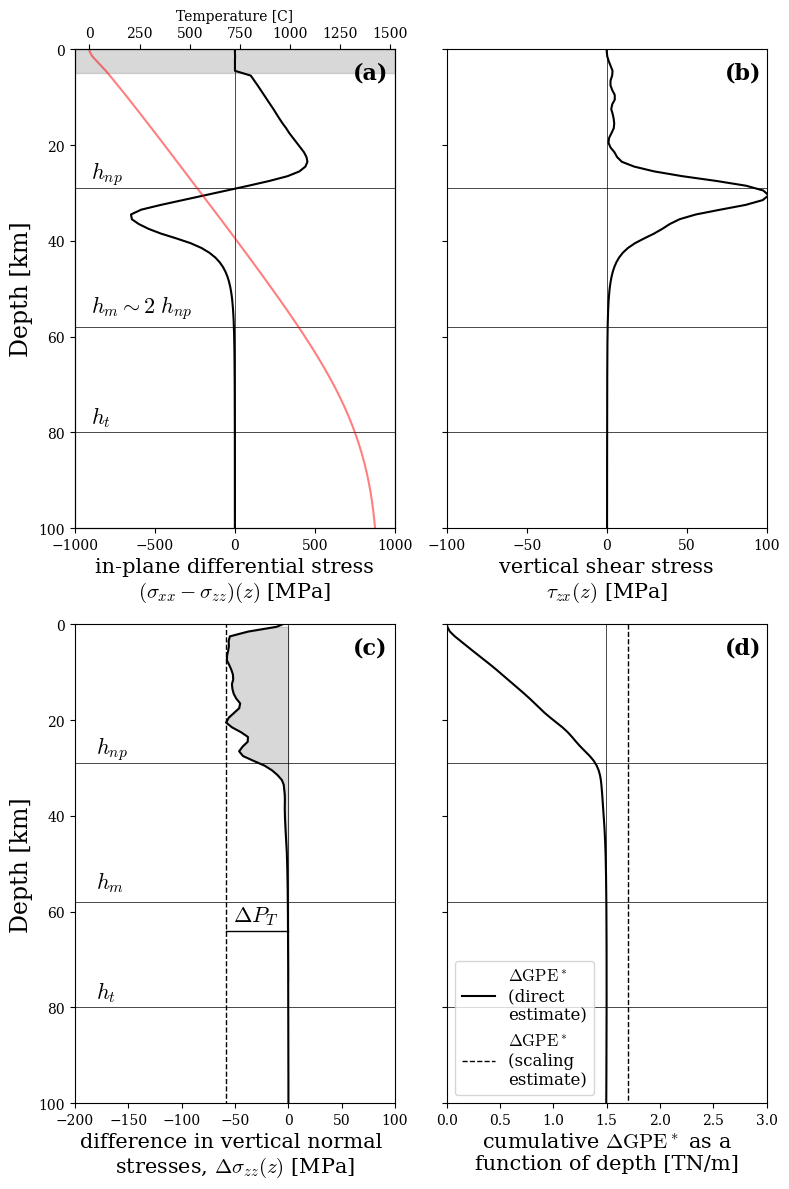

In [23]:
# Create subplots
#fig, (ax1, ax2, ax3, ax4) = plt.subplots(2, 2, figsize=(6, 12), sharey=True)

fig, ax = plt.subplots(2, 2, figsize=(8, 12), sharey=True)

ax1, ax2, ax3, ax4 = ax.flatten()

######################
ax1.plot(1e-6*(diff_stress_profile), 1e-3*czpts, c = 'k')
ax1.set_xlim(-1000, 1000)
ax1.set_ylim(100, 0)
ax1.set_xlabel("in-plane differential stress\n" + r"$(\sigma_{xx} - \sigma_{zz})(z)$ [MPa]", fontsize = 15)
ax1.vlines(0, -5, 100, color='k', lw=0.5)
ax1.hlines(1e-3*np_depth, -1000, 1000, color='k', lw=0.5)
ax1.hlines(2e-3*np_depth, -1000, 1000, color='k', lw=0.5)
ax1.hlines(80, -1000, 1000, color='k', lw=0.5)
ax1.set_ylabel("Depth [km]", fontsize = 17)
ax1b = ax1.twiny()
ax1b.plot(temp_profile - 273, 1e-3*czpts, c ='r', alpha = 0.5)
ax1b.set_xlabel(r"Temperature [C]")
ax1.axhspan(0, 5, color='grey', alpha=0.3)


#############################
ax2.plot(1e-6*(vertical_shear_stress_profile), 1e-3*czpts, c = 'k')
ax2.set_xlim(-100, 100)
ax2.set_ylim(100, 0)
ax2.set_xlabel("vertical shear stress\n" + r"$\tau_{zx}(z)$ [MPa]", fontsize = 15)
ax2.vlines(0, -5, 100, color='k', lw=0.5)
ax2.hlines(1e-3*np_depth, -500, 500, color='k', lw=0.5)
ax2.hlines(2e-3*np_depth, -500, 500, color='k', lw=0.5)
ax2.hlines(80, -500, 500, color='k', lw=0.5)



#######################
ax3.plot(1e-6*(sig_zz_iso - sig_zz_trench), 1e-3*czpts, c = 'k')
ax3.set_ylim(100, 0)
ax3.set_xlim(-200, 100)
ax3.vlines(0, -5, 100, color='k', lw=0.5, ls = '-')
ax3.set_xlabel("difference in vertical normal \nstresses, " + r"$\Delta \sigma_{zz}(z)$ [MPa]", fontsize = 15)
ax3.hlines(1e-3*np_depth, -200, 200, color='k', lw=0.5)
ax3.hlines(2e-3*np_depth, -200, 200, color='k', lw=0.5)
ax3.hlines(80, -200, 200, color='k', lw=0.5)
ax3.set_ylabel("Depth [km]", fontsize = 17)

ax3.vlines(-1e-6*trench_relative_topo*delrho*g, 
           -5, 100, color='k', lw=1, ls = '--')

ax3.fill_betweenx(  
    1e-3 * czpts,  
    1e-6 * (sig_zz_iso - sig_zz_trench),  
    0,  
    where=(1e-6 * (sig_zz_iso - sig_zz_trench) < 0),  
    color='grey', alpha=0.3  
)

#######################

#negative sign is the sign convention
ax4.plot(-1e-12*cumulative_trapezoid(sig_zz_iso - sig_zz_trench, dx = 1e3, initial=0), 1e-3*czpts, c = 'k', label =r'$\Delta \mathrm{GPE}^*$' + '\n(direct \nestimate)')
ax4.set_ylim(100, 0)
ax4.set_xlim(0, 3)
ax4.vlines(0, -5, 100, color='k', lw=0.5)
ax4.vlines(-1e-12*cumulative_trapezoid(sig_zz_iso - sig_zz_trench, dx = 1e3, initial=0)[cbase_indx], -5, 100, color='k', lw=0.5)
ax4.vlines(1e-12*gpe_est, 0, 100, color='k', lw=1, ls = '--', label = r'$\Delta \mathrm{GPE}^*$' + '\n(scaling \nestimate)')
ax4.legend(fontsize = 12, loc = 3)


ax4.set_xlabel(r"cumulative $\Delta\mathrm{GPE}^*$ as a" +  "\nfunction of depth [TN/m]",  fontsize = 15)
ax4.hlines(1e-3*np_depth, -1, 5, color='k', lw=0.5)
ax4.hlines(2e-3*np_depth, -1, 5, color='k', lw=0.5)
ax4.hlines(80, -1, 5, color='k', lw=0.5)

ax1.text(-900, 1e-3*np_depth - 2, r"$h_{np}$",  fontsize = 16)
ax1.text(-900, 78, r"$h_t$",  fontsize = 16)
ax1.text(-900, 55, r"$h_m \sim 2\;h_{np}$",  fontsize = 16)
#ax3.text(-58, 62, r"$(\rho_m - \rho_w) g w_T$",  fontsize = 14)
ax3.text(-52, 62, r"$\Delta P_T$",  fontsize = 16)

ax3.plot([-1e-6*trench_relative_topo*delrho*g, 0], [64, 64], lw=1, c='k')

ax3.text(-180, 1e-3*np_depth - 2, r"$h_{np}$",  fontsize = 16)
ax3.text(-180, 78, r"$h_t$",  fontsize = 16)
ax3.text(-180, 55, r"$h_m$",  fontsize = 16)

ax1.text(0.87, 0.94, '(a)', transform=ax1.transAxes, fontsize=16, fontweight='bold')
ax2.text(0.87, 0.94, '(b)', transform=ax2.transAxes, fontsize=16, fontweight='bold')
ax3.text(0.87, 0.94, '(c)', transform=ax3.transAxes, fontsize=16, fontweight='bold')
ax4.text(0.87, 0.94, '(d)', transform=ax4.transAxes, fontsize=16, fontweight='bold')

#g

plt.tight_layout()
plt.show()

fig.savefig('./figures/profiles.png', dpi=100, facecolor='white', bbox_inches='tight')

In [24]:
# ---------------------------------------------------------------------
# Δσ̄zz = (σ̄zz(xI) − σ̄zz(xT)) dz  →  \Delta\mathrm{GPE}^* contrast between isostatic and trench columns
# ---------------------------------------------------------------------
# The  difference in vertically integrated normal stress (Δ σ̄zz)
# between the isostatic column (x_I) and the trench column (x_T) gives the
# topgrapahic "trench pull force".

# Integrate with respect to depth (z positive downward)
integrated_value = -trapz(sig_zz_iso - sig_zz_trench, dx=1e3)  # [Pa·m]

# Convert to a percentage difference relative to the analytical GPE estimate
integrated_value = -trapz(sig_zz_iso - sig_zz_trench, dx=1e3)  # [Pa·m]
agreement_percent = 100 * (integrated_value / gpe_est)

# ---------------------------------------------------------------------
# Output
# ---------------------------------------------------------------------
print(f"\\Delta\\mathrm{{GPE}}^* from (σ̄zz(xᴵ) − σ̄zz(xᵀ))dz agrees to {agreement_percent:.2f}% with the scaling estimate")

\Delta\mathrm{GPE}^* from (σ̄zz(xᴵ) − σ̄zz(xᵀ))dz agrees to 79.46% with the scaling estimate


/var/folders/50/4pb6cyv53tq0fmpjrm94qgdc0000gn/T/ipykernel_59007/1030619459.py:9: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  integrated_value = -trapz(sig_zz_iso - sig_zz_trench, dx=1e3)  # [Pa·m]
/var/folders/50/4pb6cyv53tq0fmpjrm94qgdc0000gn/T/ipykernel_59007/1030619459.py:12: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  integrated_value = -trapz(sig_zz_iso - sig_zz_trench, dx=1e3)  # [Pa·m]


**Interpretation**
  
* Even though we integrate to a nominal compensation depth of $z_c = 100$ km, the effective depth of compensation is much less than this (the manuscript suggests that $h_m$ should be an upper limit).
* The equilibration of the difference in vertical normal stress occur around the center of the mechanical lithosphere, $z \approx h_{np}$, as predicted in the simple mechanical models in manuscript
* For the reference timestep shown in this Notebook, the directly-estimated value of the trench pull force, is about 80% of the value predicted by the scaling expression in the manuscript

## 5. Visualisation with PyVista

In [25]:
import pyvista as pv
import cmcrameri as cmc

#white background
pv.set_plot_theme("document")

In [26]:
xleft=-1600e3
zbase =660e3
data   = h5file['/Model/Params']
xspan = data[1]
zspan = data[2]
    
center = (xspan/2. +  xleft, 
              zbase - zspan/2.,
              0)

center, xspan, zspan

((0.0, 320000.0, 0), 3200000.0, 680000.0)

In [27]:
def pv_plane_from_h5(file, xleft=0, zbase =0):
    
    data   = file['/Model/Params']
    nx             = int(data[3])                   #/ No. grid points x
    nz             = int(data[4]) 
    
    xspan = data[1]
    zspan = data[2]
    
    center = (xspan/2. +  xleft, 
              zbase - zspan/2.,
              0)

    plane = pv.Plane(
        center=center,
        direction=(0, 0, -1),
        i_size=xspan,
        j_size=zspan,
        i_resolution=nx-1,
        j_resolution=nz-1,
    )
    
    return plane

def lines_from_points(points):
    """Given an array of points, make a line set"""
    poly = pv.PolyData()
    poly.points = points
    cells = np.full((len(points) - 1, 3), 2, dtype=np.int_)
    cells[:, 1] = np.arange(0, len(points) - 1, dtype=np.int_)
    cells[:, 2] = np.arange(1, len(points), dtype=np.int_)
    poly.lines = cells
    return poly

In [28]:
vtk_data =  pv_plane_from_h5(h5file, xleft=-1600e3, zbase =660e3)

vtk_data.points[:,0].max(), vtk_data.points[:,1].max(), vtk_data.points[:,1].min()

(1600000.0, 660000.0, -20000.0)

In [29]:
vtk_data.cell_data['diff_stress_xx_mpa']  = 1e-6*(np.flipud((2*h5file["/Centers"]['sxxd'][:])))
vtk_data.cell_data['phases'] = np.flipud(h5file['/VizGrid/compo'][:] )
vtk_data.cell_data['T'] = np.flipud(h5file["/Centers"]['T'][:])
                              

#map cell data to point data so you can do contours
vtk_cell_data= vtk_data.cell_data_to_point_data()

In [30]:
topo_with_zeros = np.column_stack((topo[:, 0], -1*topo[:, 1], np.zeros(topo.shape[0])))
topo_line = lines_from_points(topo_with_zeros)
topo_line.points[:, -1] -= 1

#base line
base_line = lines_from_points(np.column_stack((cxpts, 
                 z_c_depth*np.ones_like(cxpts), 
                 np.zeros_like(cxpts))))

upper_line = lines_from_points(np.column_stack((cxpts, 
                 -20e3*np.ones_like(cxpts), 
                 np.zeros_like(cxpts))))

#trench cut

trench_line = lines_from_points(np.column_stack((x_trench*np.ones_like(czpts[czpts<z_c_depth]), 
                 czpts[czpts<z_c_depth], 
                 np.zeros_like(czpts[czpts<z_c_depth]))))


xi_line = lines_from_points(np.column_stack((xi_loc*np.ones_like(czpts[czpts<z_c_depth]), 
                 czpts[czpts<z_c_depth], 
                 np.zeros_like(czpts[czpts<z_c_depth]))))

In [31]:
t_thresh = 0.9*temp_grid.max()

#show only the thermal lithosphere
thresh_1  = vtk_cell_data.threshold([273, t_thresh], 
                              scalars='T', 
                              all_scalars=False)


#this gets rid of the "air", or the material above the rock surface
thresh_2  = thresh_1.threshold([-2, -1], 
                              scalars='phases', 
                              all_scalars=False, invert=True)

#used to plot the weak layer material separately
thresh_3  = thresh_1.threshold([1.8, 2.2], 
                              scalars='phases', 
                              all_scalars=False, invert=False)


In [32]:
#contours at ...

contours = vtk_cell_data.contour(isosurfaces=[798, 1173, t_thresh - 10], 
                             scalars='T')


contours.points[:, -1] -= 1


contours2 = vtk_cell_data.contour(isosurfaces=[1200, t_thresh - 1], 
                             scalars='T')


contours2.points[:, -1] -= 1

In [33]:
sargs = dict(
    title_font_size=32,
    label_font_size=20,
    height=0.15,
    shadow=True,
    n_labels=5,
    italic=True,
    #fmt="%.1f",
    font_family="arial",
    #title = r"in-plane differential stress: $(\sigma_{xx} - \sigma_{zz})$ (Pa)"
    title = r"in-plane diff. stress: [MPa]"
)

#some versions of Pyvista support latex. Mine doesn't. 
#test..
#plotter = pv.Plotter()
#plotter.add_text(r'$\rho$')
#plotter.show()

In [34]:
cam_pos  = [(271151.1433937282, 77119.53812299849, -480542.83656951046),
 (271151.1433937282, 77119.53812299849, 0.0),
 (0.0, -1.0, 0.0)]

In [35]:

p = pv.Plotter( window_size = (600, 400), border=True, border_color='black', border_width=2.0)


p.add_mesh(thresh_2, scalars = 'diff_stress_xx_mpa', cmap=cmc.cm.vik, opacity = 1,
           clim  = [-500, 500], scalar_bar_args=sargs)


p.add_mesh(topo_line, color="black", line_width=4)
p.add_mesh(base_line, color="black", line_width=2)
p.add_mesh(upper_line, color="black", line_width=2)
p.add_mesh(trench_line, color="black", line_width=2)
p.add_mesh(xi_line, color="black", line_width=2)


p.add_mesh(contours, color="black", line_width=2)


p.add_mesh(thresh_3, scalars = 'phases',  opacity = 1, cmap ='Greys', show_scalar_bar=False)


p.camera_position = cam_pos

p.background_color = 'w'
p.enable_anti_aliasing()

#p.screenshot('./figures/model_snapshot.png')

p.render()
p.show()

Widget(value='<iframe src="http://localhost:50784/index.html?ui=P_0x300433350_0&reconnect=auto" class="pyvista…